Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')


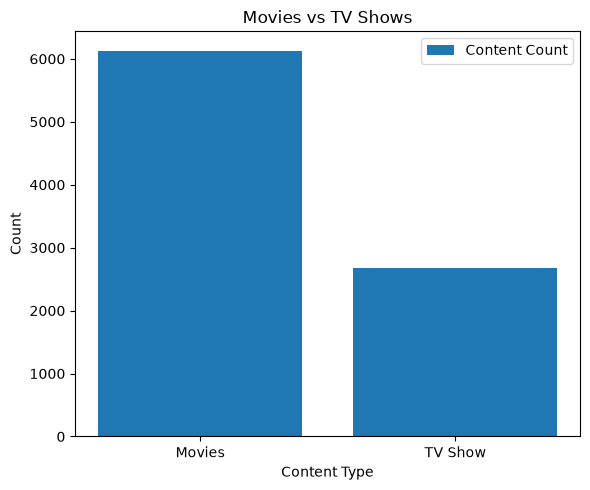

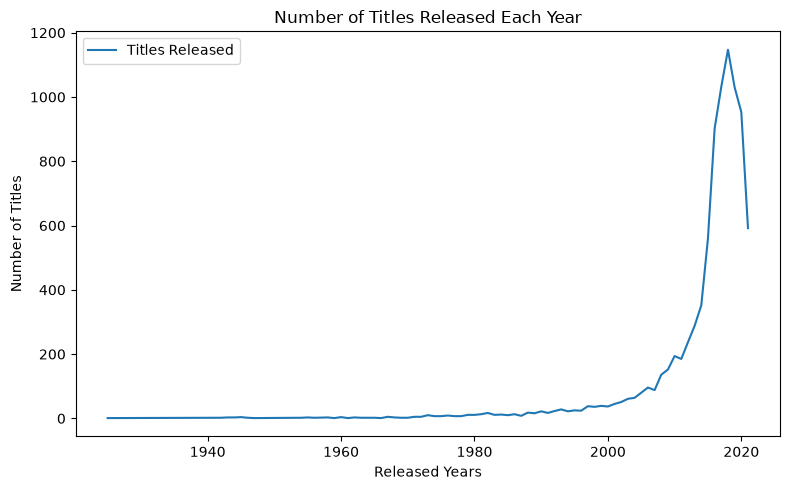

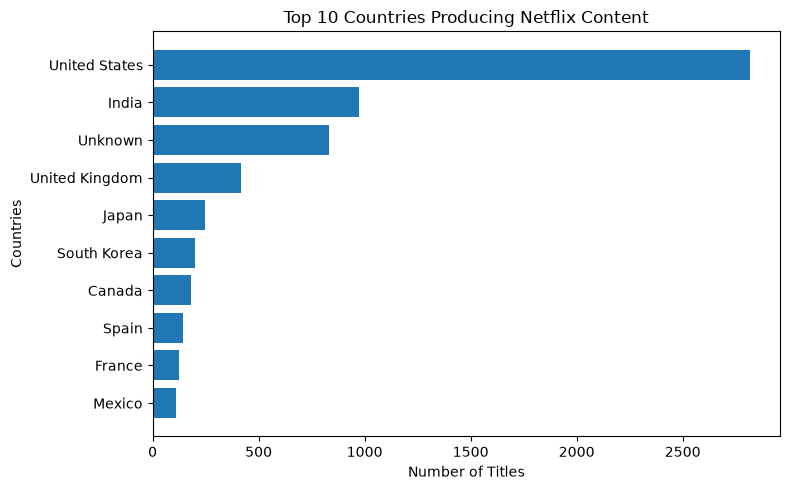

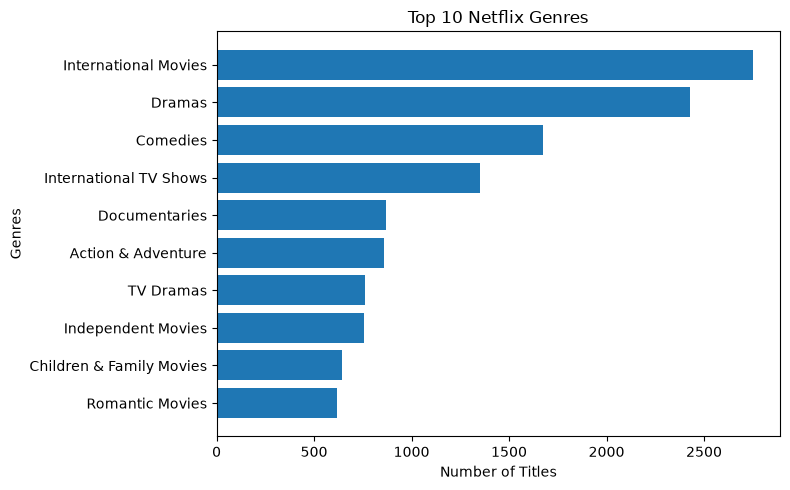

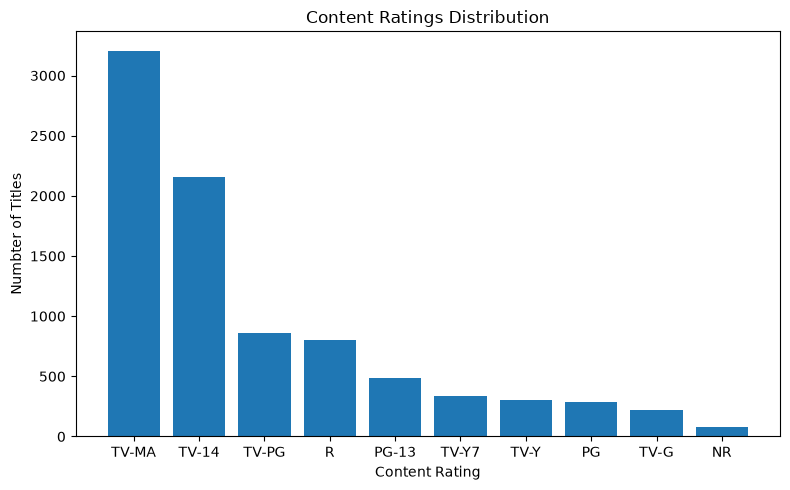

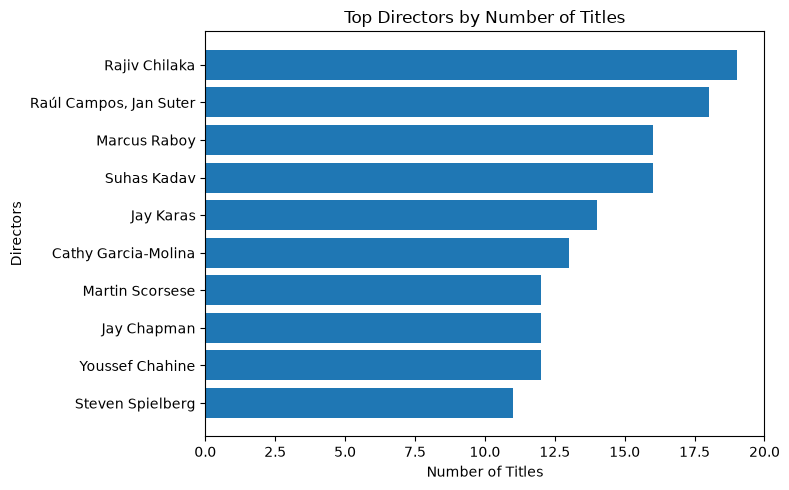

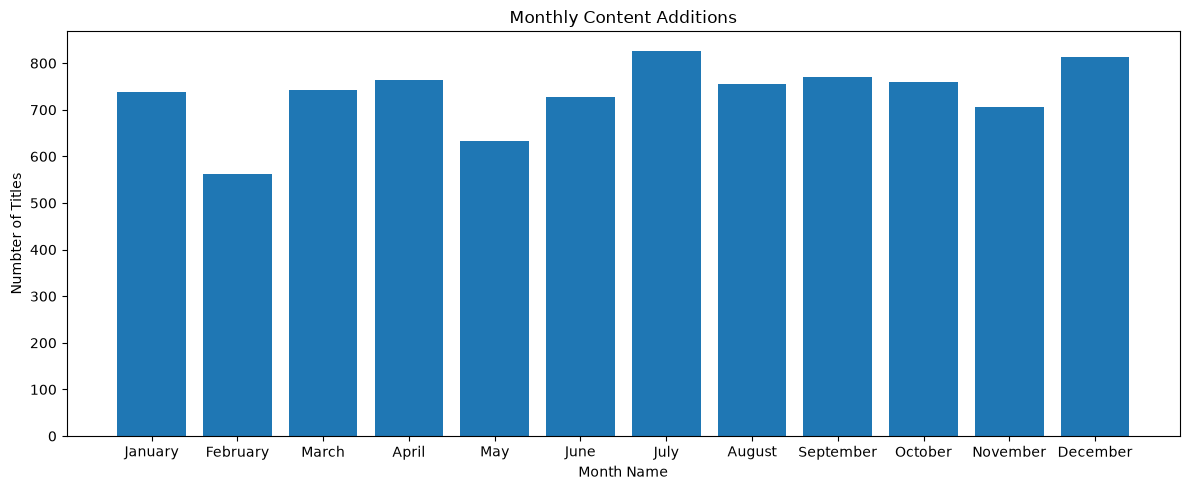

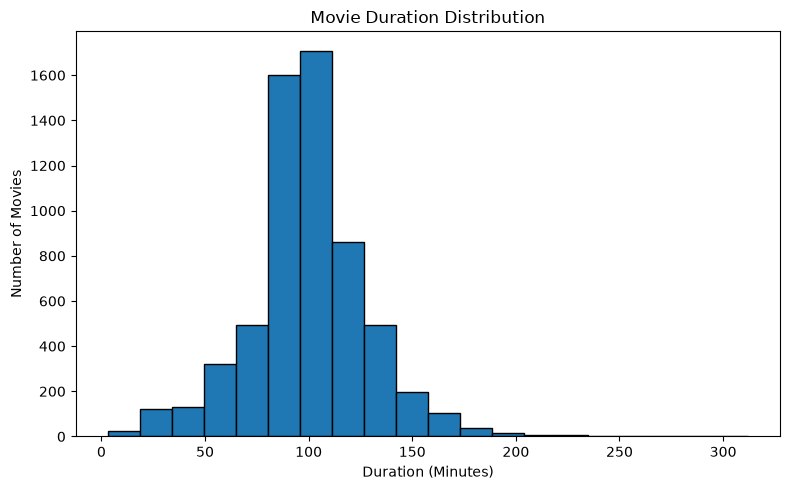

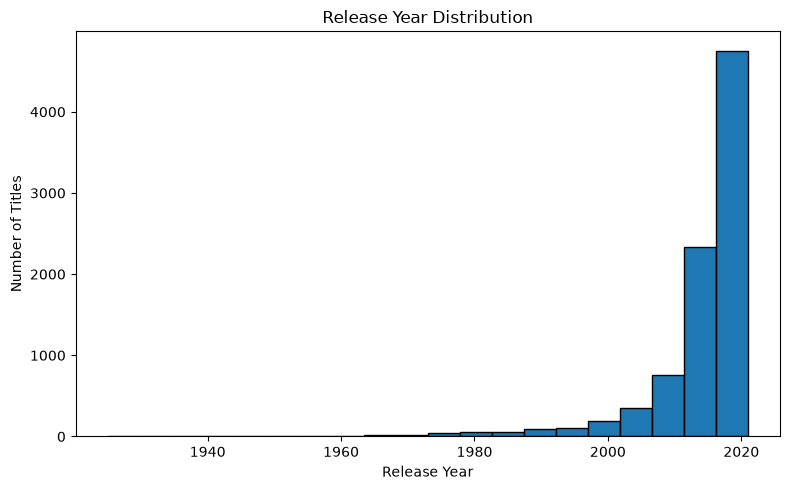

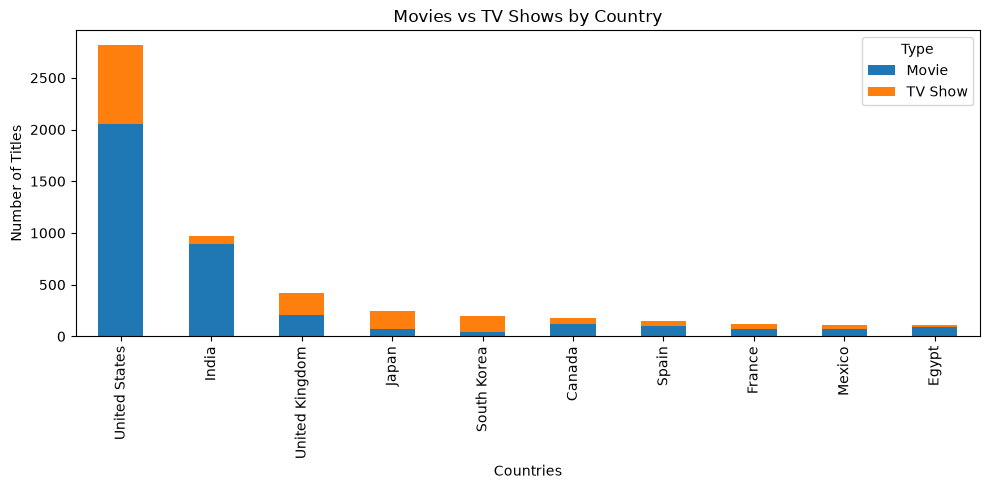

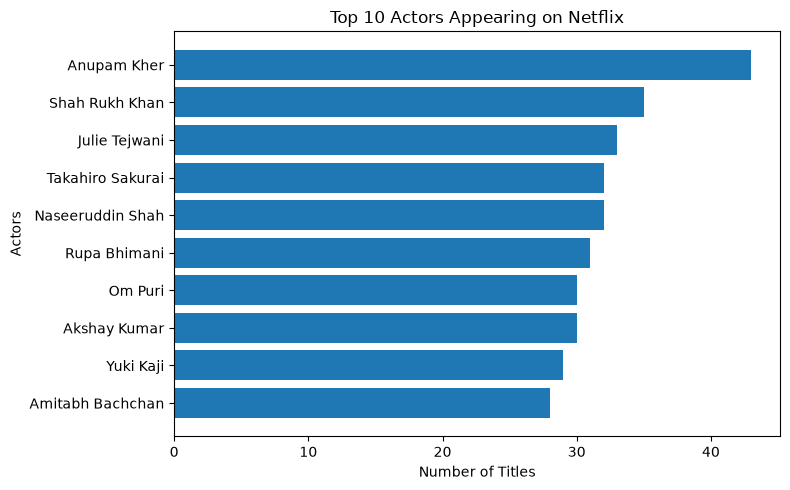

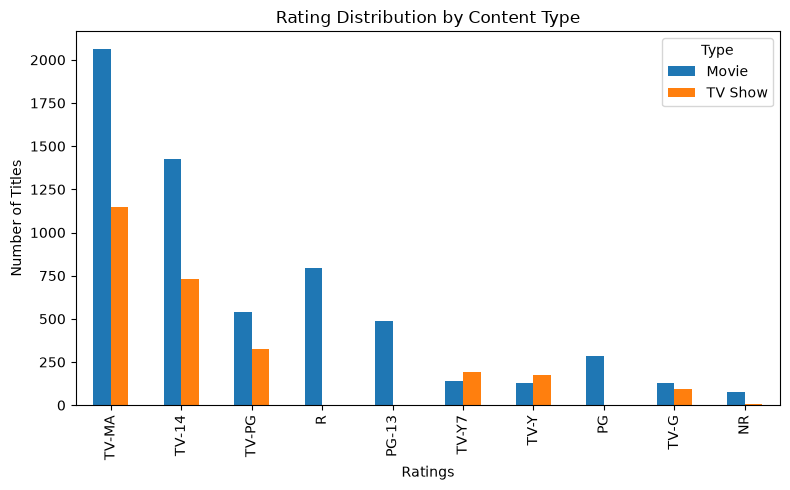

In [17]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt

#load Dataset
df = pd.read_csv('netflix_titles.csv')

#Data Cleaning 
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df["date_added"] = df["date_added"].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'])
df['rating'] = df['rating'].fillna('Unknown')
df.to_csv('netflix_titles.csv', index=False)
print(df.columns)

#Analysis & Visualization

#Insight: What type of content dominates Netflix?
movies = (df['type']=='Movie').sum()
tv_show = (df['type']=='TV Show').sum()
type = [movies, tv_show]
labels=['Movies', 'TV Show']
plt.figure(figsize=(6, 5))
plt.bar(labels, type, label= 'Content Count')
plt.title('Movies vs TV Shows')
plt.legend()
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('content_count.pdf', dpi= 300, bbox_inches= 'tight')
plt.show()

#Insight: Analyze trends in the number of movies and TV shows released each year, highlighting periods of increased or decreased content production.
no_of_titles = df.groupby('release_year')['title'].count()
plt.figure(figsize=(8, 5))
plt.plot(no_of_titles.index, no_of_titles.values, label='Titles Released')
plt.legend()
plt.title('Number of Titles Released Each Year')
plt.xlabel('Released Years')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.savefig('no_of_title.pdf', dpi= 300, bbox_inches= 'tight')
plt.show()

#Insight: Which countries contribute the most titles to Netflix.
countries = df.groupby('country')['title'].count()
most_titles = countries.nlargest(10).sort_values()
plt.figure(figsize=(8, 5))
plt.barh(most_titles.index, most_titles.values)
plt.title('Top 10 Countries Producing Netflix Content')
plt.xlabel('Number of Titles')
plt.ylabel('Countries')
plt.tight_layout()
plt.savefig('countries.pdf', dpi= 300, bbox_inches= 'tight')
plt.show()

#Insight: What genres Netflix focuses on the most.
genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10).sort_values()
plt.figure(figsize=(8, 5))
plt.barh(top_genres.index, top_genres.values)
plt.title('Top 10 Netflix Genres')
plt.xlabel('Number of Titles')
plt.ylabel('Genres')
plt.tight_layout()
plt.savefig('top_genres.pdf', dpi= 300, bbox_inches= 'tight')
plt.show()

#Insight: Is Netflix more family-friendly or adult-oriented?
rating = df['rating'].value_counts().head(10)
plt.figure(figsize=(8, 5))
plt.bar(rating.index, rating.values)
plt.title('Content Ratings Distribution')
plt.xlabel('Content Rating')
plt.ylabel('Numbter of Titles')
plt.tight_layout()
plt.savefig('rating.pdf', dpi= 300, bbox_inches= 'tight')
plt.show()

#Insight: Which directors appear most frequently on Netflix.
top_director = (df[df['director'] != 'Unknown']['director'].value_counts().head(10).sort_values())
plt.figure(figsize=(8, 5))
plt.barh(top_director.index, top_director.values)
plt.title('Top Directors by Number of Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Directors')
plt.xlim(0, 20)
plt.tight_layout()
plt.savefig('top_director.pdf', dpi= 300, bbox_inches= 'tight')
plt.show()

#Insight: During which months Netflix tends to add the most content.
month_order= [
    'January', 'February', 'March', 'April', 'May', 'June', 
    'July', 'August', 'September', 'October', 'November', 'December'
]
df['month'] = df['date_added'].dt.month_name()
content = df['month'].value_counts().reindex(month_order)
plt.figure(figsize=(12, 5))
plt.bar(content.index, content.values)
plt.title('Monthly Content Additions')
plt.xlabel('Month Name')
plt.ylabel('Numbter of Titles')
plt.tight_layout()
plt.savefig('month.pdf', dpi= 300, bbox_inches= 'tight')
plt.show()

#Insight: What is the typical movie length? Are most movies around 90–120 minutes?
movies = df[df['type'] == 'Movie'].copy()
movies = movies.dropna(subset=['duration'])
movies['duration_min'] = movies['duration'].str.extract(r'(\d+)').astype(int)
plt.figure(figsize=(8, 5))
plt.hist(movies['duration_min'], bins=20, edgecolor='black')
plt.title('Movie Duration Distribution')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.savefig('movie_duration.pdf', dpi=300, bbox_inches='tight')
plt.show()

#Insight: Does Netflix mostly feature newer releases or older content?
plt.figure(figsize=(8, 5))
plt.hist(df['release_year'], bins=20, edgecolor='black')
plt.title('Release Year Distribution')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.savefig('release_distribution.pdf', dpi=300, bbox_inches='tight')
plt.show()

#Insight: Which countries produce more movies versus TV shows.
country_type = pd.crosstab(df[df['country'] != 'Unknown']['country'], df['type'])
top10 = country_type.sum(axis=1).nlargest(10).index
country_type.loc[top10].plot(
    kind='bar',
    stacked=True,
    figsize=(10, 5)
)
plt.title('Movies vs TV Shows by Country')
plt.xlabel('Countries')
plt.ylabel('Number of Titles')
plt.legend(title='Type')
plt.tight_layout()
plt.savefig('movie_vs_tvshows.pdf', dpi=300, bbox_inches='tight')
plt.show()

#Insight: Which actors are featured most often in the dataset.
actors = df[df['cast'] != 'Unknown']['cast'].str.split(', ').explode()
top_actors = actors.value_counts().head(10).sort_values()
plt.figure(figsize=(8, 5))
plt.barh(top_actors.index, top_actors.values)
plt.title('Top 10 Actors Appearing on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Actors')
plt.tight_layout()
plt.savefig('top_actors.pdf', dpi= 300, bbox_inches= 'tight')
plt.show()

#Insight: Do movies and TV shows target different audiences?
rating_type = pd.crosstab(df['rating'], df['type'])
top10 = rating_type.sum(axis=1).nlargest(10).index
rating_type.loc[top10].plot(
    kind='bar',
    figsize=(8,5)
)
plt.title('Rating Distribution by Content Type')
plt.xlabel('Ratings')
plt.ylabel('Number of Titles')
plt.legend(title='Type')
plt.tight_layout()
plt.savefig('rating_vs_content.pdf', dpi=300, bbox_inches='tight')
plt.show()

